<a href="https://colab.research.google.com/github/ajzal4you/Master-Project-/blob/main/Segmantation_Brain_Tumour_MRI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nibabel
!pip install matplotlib
!pip install scikit-learn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/AI_MRI_Project/Task01_BrainTumour.tar

/content/drive/MyDrive/AI_MRI_Project/Task01_BrainTumour.tar


In [ ]:
!tar -xvf /content/drive/MyDrive/AI_MRI_Project/Task01_BrainTumour.tar -C /content/

Task01_BrainTumour/._dataset.json
Task01_BrainTumour/dataset.json
Task01_BrainTumour/._imagesTr
Task01_BrainTumour/imagesTr/
Task01_BrainTumour/imagesTr/BRATS_457.nii.gz
Task01_BrainTumour/imagesTr/BRATS_306.nii.gz
Task01_BrainTumour/imagesTr/BRATS_206.nii.gz
Task01_BrainTumour/imagesTr/BRATS_449.nii.gz
Task01_BrainTumour/imagesTr/BRATS_318.nii.gz
Task01_BrainTumour/imagesTr/BRATS_218.nii.gz
Task01_BrainTumour/imagesTr/BRATS_434.nii.gz
Task01_BrainTumour/imagesTr/BRATS_365.nii.gz
Task01_BrainTumour/imagesTr/BRATS_265.nii.gz
Task01_BrainTumour/imagesTr/BRATS_214.nii.gz
Task01_BrainTumour/imagesTr/BRATS_314.nii.gz
Task01_BrainTumour/imagesTr/BRATS_445.nii.gz
Task01_BrainTumour/imagesTr/BRATS_269.nii.gz
Task01_BrainTumour/imagesTr/BRATS_369.nii.gz
Task01_BrainTumour/imagesTr/BRATS_438.nii.gz
Task01_BrainTumour/imagesTr/BRATS_277.nii.gz
Task01_BrainTumour/imagesTr/BRATS_377.nii.gz
Task01_BrainTumour/imagesTr/BRATS_426.nii.gz
Task01_BrainTumour/imagesTr/BRATS_095.nii.gz
Task01_BrainTumour/i

In [ ]:
!ls /content/Task01_BrainTumour

dataset.json  imagesTr	imagesTs  labelsTr


In [ ]:
image_dir = "/content/drive/MyDrive/AI_MRI_Project/Task01_BrainTumour/imagesTr"
label_dir = "/content/drive/MyDrive/AI_MRI_Project/Task01_BrainTumour/labelsTr"

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from sklearn.model_selection import train_test_split

In [ ]:
class BrainMRISliceDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.filenames = sorted(os.listdir(image_dir))

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.filenames[idx])
        mask_path = os.path.join(self.mask_dir, self.filenames[idx])

        img = nib.load(img_path).get_fdata()  # [H, W, D]
        mask = nib.load(mask_path).get_fdata()

        # Take center slice
        d = img.shape[-1] // 2
        img = img[:, :, d]
        mask = mask[:, :, d]

        # Resize to (240, 240) if needed
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return img, masks

In [ ]:
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        self.enc1 = self.conv_block(1, 16)
        self.enc2 = self.conv_block(16, 32)
        self.pool = nn.MaxPool2d(2, 2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec1 = self.conv_block(32, 16)
        self.out_conv = nn.Conv2d(16, 1, kernel_size=1)

    def conv_block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.pool(x1)
        x3 = self.enc2(x2)
        x4 = self.up(x3)
        x5 = self.dec1(x4)
        return torch.sigmoid(self.out_conv(x5))

In [ ]:
image_dir = "/content/Task01_BrainTumour/imagesTr"
label_dir = "/content/Task01_BrainTumour/labelsTr"

dataset = BrainMRISegmentationDataset(image_dir, label_dir)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

# Sanity check
img, mask = dataset[0]
print("Image shape:", img.shape)
print("Mask shape:", mask.shape)

Image shape: torch.Size([4, 240, 240])
Mask shape: torch.Size([1, 240, 240])


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
# Re-create the dataset with the corrected class
image_dir = "/content/Task01_BrainTumour/imagesTr"
label_dir = "/content/Task01_BrainTumour/labelsTr"
dataset = BrainMRISegmentationDataset(image_dir, label_dir)

# Split the dataset into training and validation sets
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create DataLoaders for training and validation
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True) # Reduced batch size for potential memory issues
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)

# Ensure model, criterion, and optimizer are defined (assuming they are defined in previous cells)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device) # Assuming UNet is defined and is the correct model
criterion = nn.BCEWithLogitsLoss() # Adjust based on your model output and task
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        # Masks are already [Batch, 1, H, W] from the corrected dataset, so no need to unsqueeze(1)
        masks = masks.float() # Ensure mask is float for BCEWithLogitsLoss

        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

Epoch 1/5, Loss: 78.2596
Epoch 2/5, Loss: 15.4494
Epoch 3/5, Loss: 9.2872
Epoch 4/5, Loss: -0.4988
Epoch 5/5, Loss: -2.0189


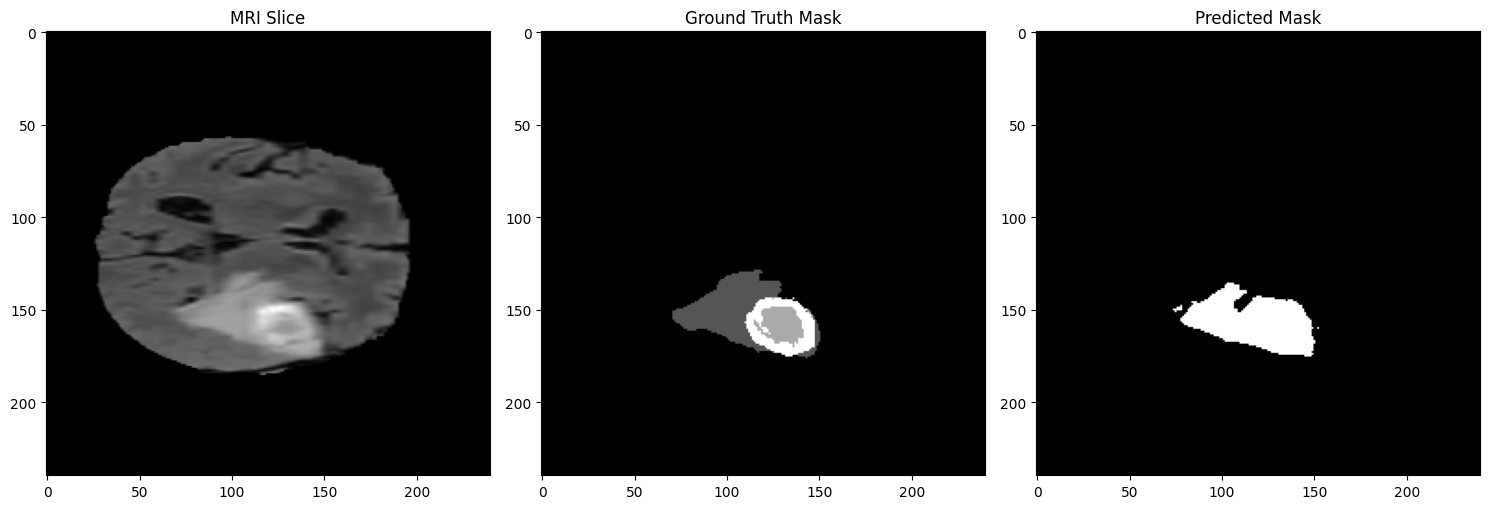

In [ ]:
model.eval()
sample_img, sample_mask = dataset[0] # Changed full_dataset to dataset
with torch.no_grad():
    input_tensor = sample_img.unsqueeze(0).to(device)
    output = torch.sigmoid(model(input_tensor)).squeeze().cpu().numpy()

binary_mask = (output > 0.5).astype(np.uint8)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(sample_img.squeeze().cpu().numpy()[0], cmap='gray') # Added .cpu().numpy()[0] to handle channels
plt.title("MRI Slice")

plt.subplot(1, 3, 2)
plt.imshow(sample_mask.squeeze().cpu().numpy(), cmap='gray') # Added .squeeze().cpu().numpy()
plt.title("Ground Truth Mask")

plt.subplot(1, 3, 3)
plt.imshow(binary_mask, cmap='gray')
plt.title("Predicted Mask")

plt.tight_layout()
plt.show()

In [ ]:
image = image[0]
mask = masks[0]
output = modfel(image.unsqueeze(0).to(device))
pred= torch.sigmoid(output).squeeze().detach().cpu()

NameError: name 'image' is not defined

NameError: name 'img_slice' is not defined

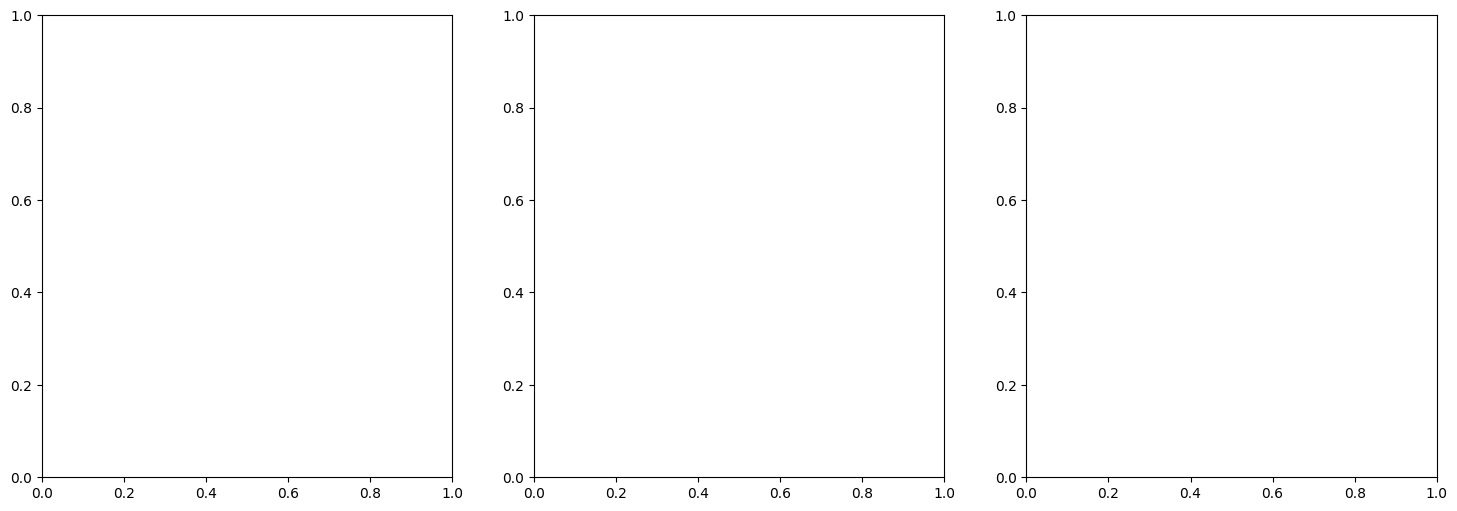

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].imshow(img_slice.cpu(), cmap='gray')
axs[0].set_title("MRI Slice")
axs[1].imshow(mask_slice.cpu(), cmap='gray')
axs[1].set_title("Ground Truth")
axs[2].imshow(binary_mask, cmap='gray')
axs[2].set_title("Predicted Mask")
plt.tight_layout()
plt.show()

In [ ]:
dataset = BrainMRISegmentationDataset(
    image_dir="/content/Task01_BrainTumour/imagesTr",
    label_dir="/content/Task01_BrainTumour/labelsTr"
)

NameError: name 'BrainMRISegmentationDataset' is not defined

In [ ]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])


NameError: name 'dataset' is not defined

In [ ]:
#DataLoaders
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)

NameError: name 'train_dataset' is not defined

In [ ]:
torch.save(model.state_dict(), 'unet_model.pth')

NameError: name 'model' is not defined